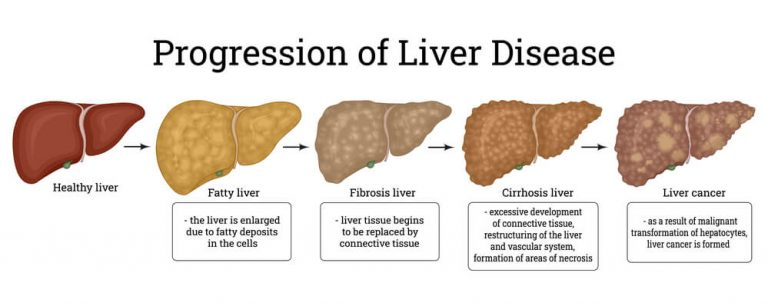

> # Dataset Overview

This dataset contains **liver ultrasound images** used for liver fibrosis stage classification and segmentation. Each image is associated with a segmentation mask and a fibrosis grade.

Liver fibrosis refers to the progressive accumulation of scar tissue in the liver, usually caused by long-term liver injury. As fibrosis progresses, the liver gradually loses its normal structure and function.

In this dataset, the fibrosis severity is divided into three grades:

* **Grade 1:** Mild fibrosis — early-stage changes with limited fibrosis.
* **Grade 2:** Moderate fibrosis — increased accumulation of fibrotic tissue and more noticeable structural changes.
* **Grade 3:** Severe fibrosis — advanced fibrosis with extensive scarring and significant structural changes.

The dataset is used to train a deep learning model to learn the relationship between ultrasound images, their segmentation masks, and the corresponding fibrosis grade.


In [2]:
import os 
import cv2
import json
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import warnings 
warnings.filterwarnings('ignore')

from collections import defaultdict
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import losses
from tensorflow.keras import callbacks
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Conv2D, MaxPooling2D , GlobalAveragePooling2D,Dropout,BatchNormalization,Input,Flatten,Dense
from tensorflow.keras.applications import EfficientNetB0 ,DenseNet121

from IPython.display import clear_output
!pip install tf_explain
clear_output()

from keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from tf_explain.core.grad_cam import GradCAM

from keras.metrics import MeanIoU

In [3]:
BASE_PATH = "/kaggle/input/datasets/sohailaelsayed/final-masald-dataset/final merge dataset/final merge dataset"
data = []

# Grades
for grade in ["Grade_1", "Grade_2", "Grade_3"]:
    
    radiology_dir = os.path.join(BASE_PATH, grade, "Radiology")
    masks_dir = os.path.join(BASE_PATH, grade, "Masks")
    
    radiology_files = os.listdir(radiology_dir)
    
    for radiology_file in radiology_files:
        
        if not radiology_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
    
        image_id = os.path.splitext(radiology_file)[0]
        
        mask_file = image_id + ".png"
        mask_path = os.path.join(masks_dir, mask_file)
        
        radiology_path = os.path.join(radiology_dir, radiology_file)
        
        if os.path.exists(mask_path):
            
            data.append({
                "image_path": radiology_path,
                "mask_path": mask_path,
                "label": grade
            })

df = pd.DataFrame(data)

print("Number of samples:", len(df))
df.head()

Number of samples: 2031


,image_path,mask_path,label
0,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
1,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
2,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
3,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1
4,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1


In [4]:
df.shape

(2031, 3)

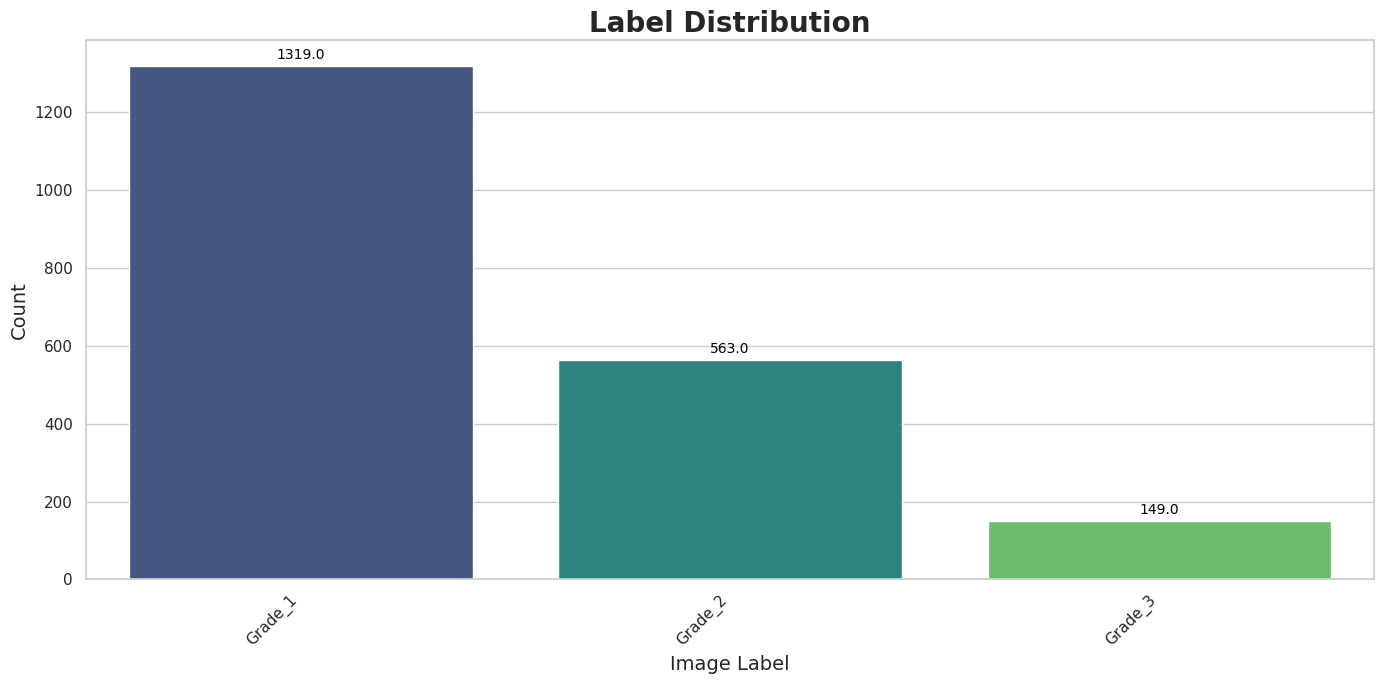

In [5]:
sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, x='label', palette='viridis', order=df['label'].value_counts().index)

plt.title("Label Distribution", fontsize=20, fontweight='bold')
plt.xlabel("Image Label", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 8),
                textcoords='offset points')
plt.tight_layout()
plt.show()

In [6]:
df_grade1 = df[df['label']=='Grade_1'].head(1)
df_grade2 = df[df['label']=='Grade_2'].head(1)
df_grade3 = df[df['label']=='Grade_3'].head(1)

In [7]:
df_grade1

,image_path,mask_path,label
0,/kaggle/input/datasets/sohailaelsayed/final-ma...,/kaggle/input/datasets/sohailaelsayed/final-ma...,Grade_1


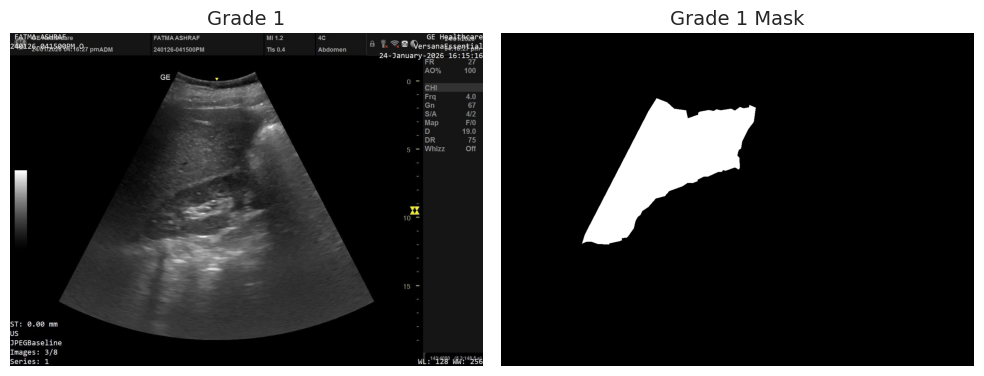

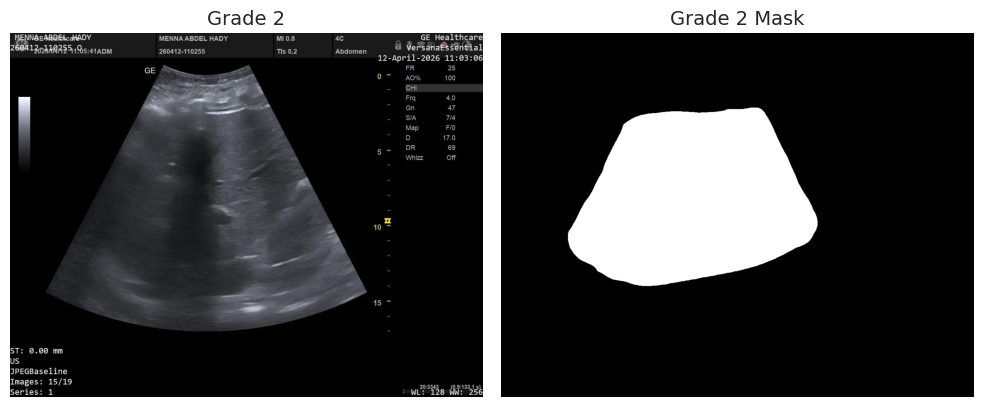

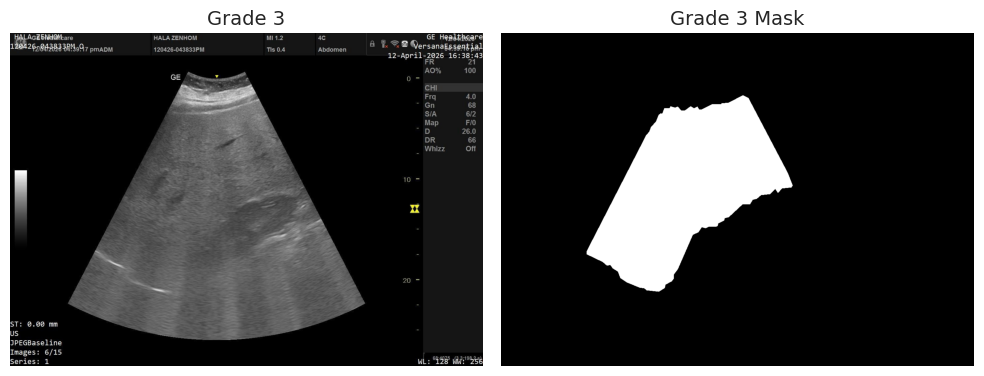

In [8]:
grades = {
    "Grade 1": df_grade1,
    "Grade 2": df_grade2,
    "Grade 3": df_grade3
}

for grade_name, df_grade in grades.items():

    plt.figure(figsize=(10, 5))
    row = df_grade.iloc[0]
    img = Image.open(row["image_path"])
    mask_path = row["mask_path"]

    if isinstance(mask_path, str):
        mask = Image.open(mask_path)
    else:
        mask = None
        
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(grade_name, fontsize=14)
    plt.subplot(1, 2, 2)

    if mask is not None:
        plt.imshow(mask, cmap="gray")
        plt.title(f"{grade_name} Mask", fontsize=14)
    else:
        plt.title("No Mask")

    plt.axis("off")

    plt.tight_layout()
    plt.show()

> # ***Show Sample of Data*** 

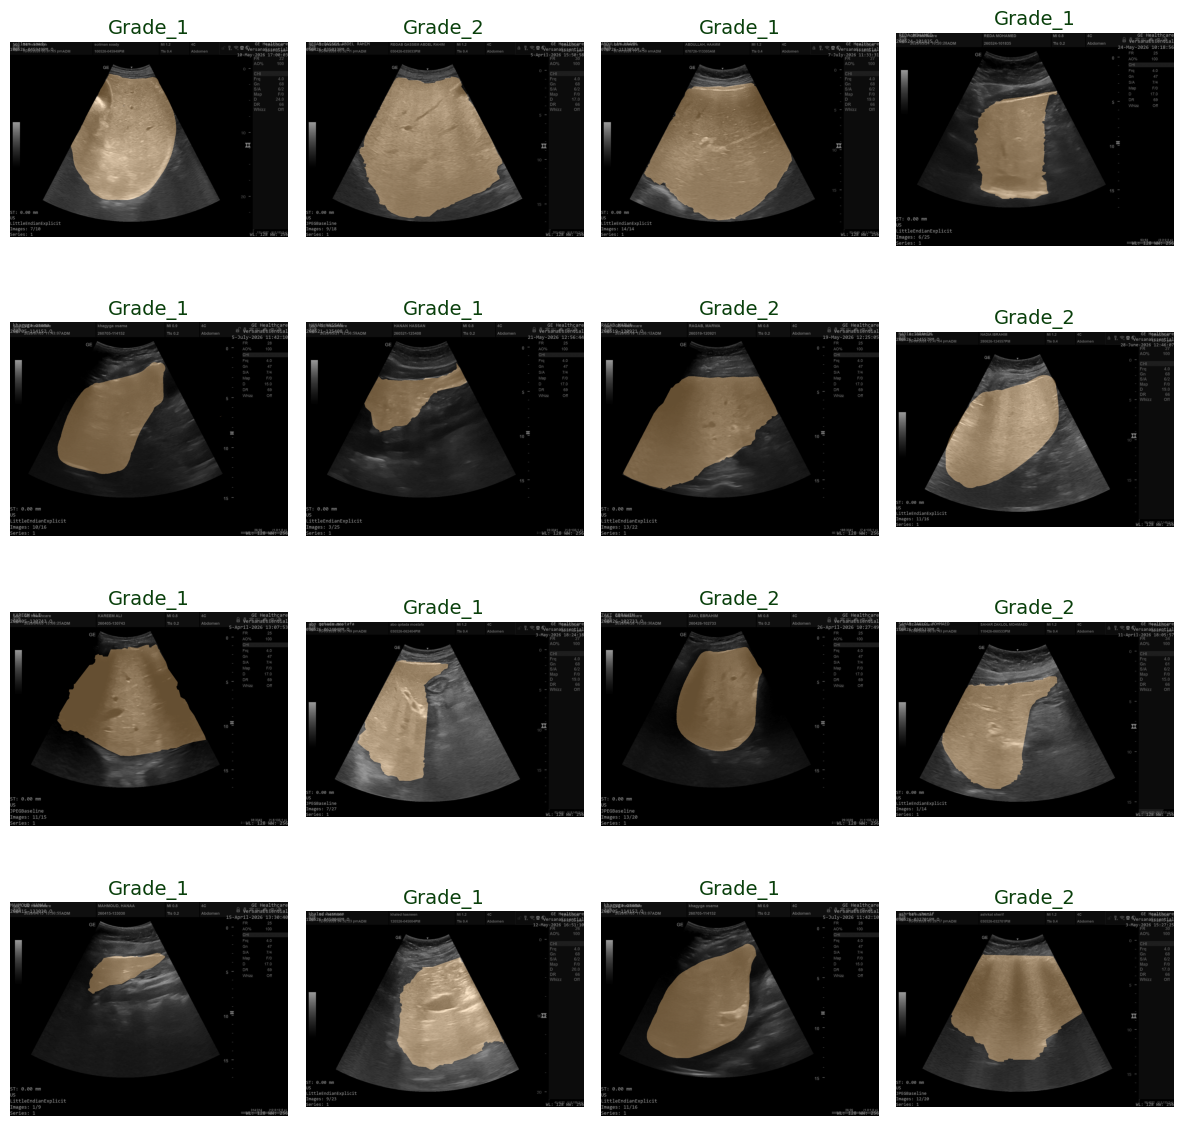

In [9]:
df = df.sample(frac=1).reset_index(drop=True)
plt.figure(figsize=(12, 12))

for i in range(16):
    img_path = df.iloc[i]['image_path']
    img = np.array(Image.open(img_path).convert("L"))
    mask_path = df.iloc[i]['mask_path']

    if isinstance(mask_path, list) and len(mask_path) > 0:
        mask_path = mask_path[0]

    if mask_path is not None:
        mask = np.array(Image.open(mask_path).convert("L"))
    else:
        mask = None
        
    plt.subplot(4, 4, i + 1)

    plt.imshow(img, cmap="gray")
    if mask is not None:
        plt.imshow(mask, cmap="copper", alpha=0.4)
    label_name = df.iloc[i]['label']
    plt.title(label_name, color='#0A400C', fontsize=14)

    plt.axis("off")

plt.tight_layout()
plt.show()

> # ***Hyperparameters*** 

In [10]:
batchsize    = 32
image_height = 224
image_width  = 224
num_classes  = 3
epochs       = 20

In [11]:
def load_image_mask(image_path, mask_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (224, 224))
    mask = tf.cast(mask, tf.float32) / 255.0

    return image, mask, label

In [12]:
train_df, validation_df = train_test_split(
    df,
    test_size=0.1,
    shuffle=True,
    random_state=42,
    stratify=df['label']
)

In [13]:
print("Train:", len(train_df))
print("Validation:", len(validation_df))

print("\nTrain distribution:")
print(train_df['label'].value_counts(normalize=True))

print("\nValidation distribution:")
print(validation_df['label'].value_counts(normalize=True))

Train: 1827
Validation: 204

Train distribution:
label
Grade_1    0.649699
Grade_2    0.276957
Grade_3    0.073344
Name: proportion, dtype: float64

Validation distribution:
label
Grade_1    0.647059
Grade_2    0.279412
Grade_3    0.073529
Name: proportion, dtype: float64


In [14]:
class_names = sorted(df['label'].unique())
class_to_idx = {
    name: idx for idx, name in enumerate(class_names)
}
train_df['label_id'] = train_df['label'].map(class_to_idx)
validation_df['label_id'] = validation_df['label'].map(class_to_idx)

In [15]:
def augment(image, mask,label):
    seed = tf.random.uniform(
        [2],
        maxval=100000,
        dtype=tf.int32
    )

    image = tf.image.stateless_random_flip_left_right(
        image,
        seed=seed
    )

    mask = tf.image.stateless_random_flip_left_right(
        mask,
        seed=seed
    )

    return image, mask , label

In [16]:
def combine_image_mask(image, mask, label):
    combined = tf.concat([image, mask], axis=-1)

    return combined, label

In [17]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df['image_path'].values,
        train_df['mask_path'].values,
        train_df['label_id'].values
    )
)

train_ds = train_ds.map(
    load_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.map(
    augment,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.map(
    combine_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(batchsize)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

I0000 00:00:1790525550.448908      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790525550.451630      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [18]:
validation_ds = tf.data.Dataset.from_tensor_slices(
    (
        validation_df['image_path'].values,
        validation_df['mask_path'].values,
        validation_df['label_id'].values
    )
)

validation_ds = validation_ds.map(
    load_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.map(
    combine_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.batch(batchsize)

validation_ds = validation_ds.prefetch(
    tf.data.AUTOTUNE
)

In [19]:
print("Train samples:", len(train_df))
print("Validation samples:", len(validation_df))

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_ds).numpy())

print("Batch size:", batchsize)

Train samples: 1827
Validation samples: 204
Train batches: 58
Validation batches: 7
Batch size: 32


> # Data Augmentation

On-the-fly augmentation was applied using a random horizontal flip to both the image and its corresponding mask with the same seed, ensuring proper alignment.

This approach does not create or store additional images, so it **saves storage space** while providing different image variations across training epochs. It is a **simple, lightweight, and storage-efficient** augmentation technique that helps reduce overfitting.


In [20]:
lr_callback   = callbacks.ReduceLROnPlateau(monitor= 'val_accuracy',factor = 0.1,patience=5)
stop_callback = callbacks.EarlyStopping(monitor= 'val_accuracy',patience=8)
model_ckpt = callbacks.ModelCheckpoint("efficientnetb0_model.h5",save_best_only=True,monitor="val_accuracy",mode="max")

> # ***DenseNet121*** 

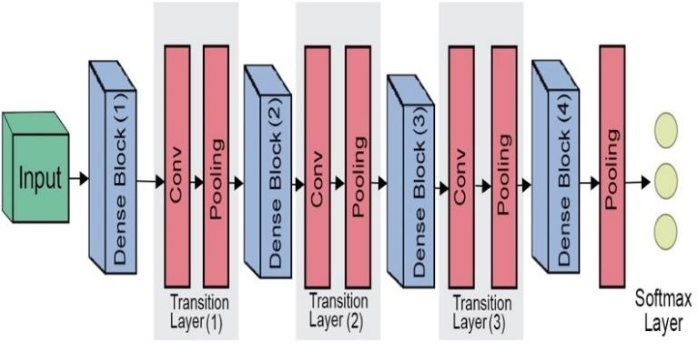

In [27]:
model_ckpt = callbacks.ModelCheckpoint("densenet121_model.h5",save_best_only=True,monitor="val_accuracy",mode="max")

In [28]:
def build_model():
    inputs = layers.Input(
        shape=(image_width, image_height, 4),
        name="image_mask_input"
    )
    x = layers.Conv2D(
        filters=3,
        kernel_size=1,
        padding='same',
        name='convert_4_to_3'
    )(inputs)

    #DenseNet121
    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(image_width, image_height, 3)
    )

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4, name='top_dropout')(x)

    output = layers.Dense(
        num_classes,
        activation='softmax',
        name='pred'
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=output,
        name='DENSENET_Image_Mask'
    )

    optimizer = optimizers.Adam(
        learning_rate=1e-3
    )

    loss = losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    model.summary()

    return model

In [29]:
model = build_model()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DENSENET_Image_Mask"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_mask_input (InputLayer)   │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convert_4_to_3 (Conv2D)         │ (None, 224, 224, 3)    │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,044,690 (26.87 MB)

 Trainable params: 6,958,994 (26.55 MB)

 Non-trainable params: 85,696 (334.75 KB)

> # ***Train Model*** 

In [30]:
history = model.fit(
    train_ds,
    validation_data = validation_ds,
    callbacks = [lr_callback,stop_callback,model_ckpt],
    epochs = epochs,
    verbose =1
)

Epoch 1/20


2026-09-27 16:18:01.828105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-27 16:18:01.975037: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.5118 - loss: 1.4272

2026-09-27 16:20:05.171611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-27 16:20:05.311671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-27 16:22:18.924692: E external/local_xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module a_inference_one_step_on_data_144240__.54575] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5130 - loss: 1.4220   

...

58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 330ms/step - accuracy: 0.9540 - loss: 0.1258 - val_accuracy: 0.8039 - val_loss: 0.9600 - learning_rate: 0.0010
Epoch 12/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 309ms/step - accuracy: 0.9852 - loss: 0.0440 - val_accuracy: 0.7892 - val_loss: 1.0252 - learning_rate: 0.0010
Epoch 13/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 310ms/step - accuracy: 0.9639 - loss: 0.1024 - val_accuracy: 0.7696 - val_loss: 1.2683 - learning_rate: 0.0010
Epoch 14/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 310ms/step - accuracy: 0.9628 - loss: 0.0911 - val_accuracy: 0.4167 - val_loss: 3.0173 - learning_rate: 0.0010
Epoch 15/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 309ms/step - accuracy: 0.9847 - loss: 0.0412 - val_accuracy: 0.7696 - val_loss: 0.9039 - learning_rate: 0.0010
Epoch 16/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9737 - loss: 0.0797

58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 330ms/step - accuracy: 0.9847 - loss: 0.0513 - val_accuracy: 0.8971 - val_loss: 0.3609 - learning_rate: 0.0010
Epoch 17/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 308ms/step - accuracy: 0.9923 - loss: 0.0263 - val_accuracy: 0.1863 - val_loss: 6.7887 - learning_rate: 0.0010
Epoch 18/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9960 - loss: 0.0169

58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 331ms/step - accuracy: 0.9956 - loss: 0.0164 - val_accuracy: 0.9559 - val_loss: 0.0839 - learning_rate: 0.0010
Epoch 19/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9924 - loss: 0.0148

58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 328ms/step - accuracy: 0.9945 - loss: 0.0120 - val_accuracy: 0.9755 - val_loss: 0.0763 - learning_rate: 0.0010
Epoch 20/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9988 - loss: 0.0043

58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 330ms/step - accuracy: 0.9989 - loss: 0.0050 - val_accuracy: 0.9902 - val_loss: 0.0579 - learning_rate: 0.0010


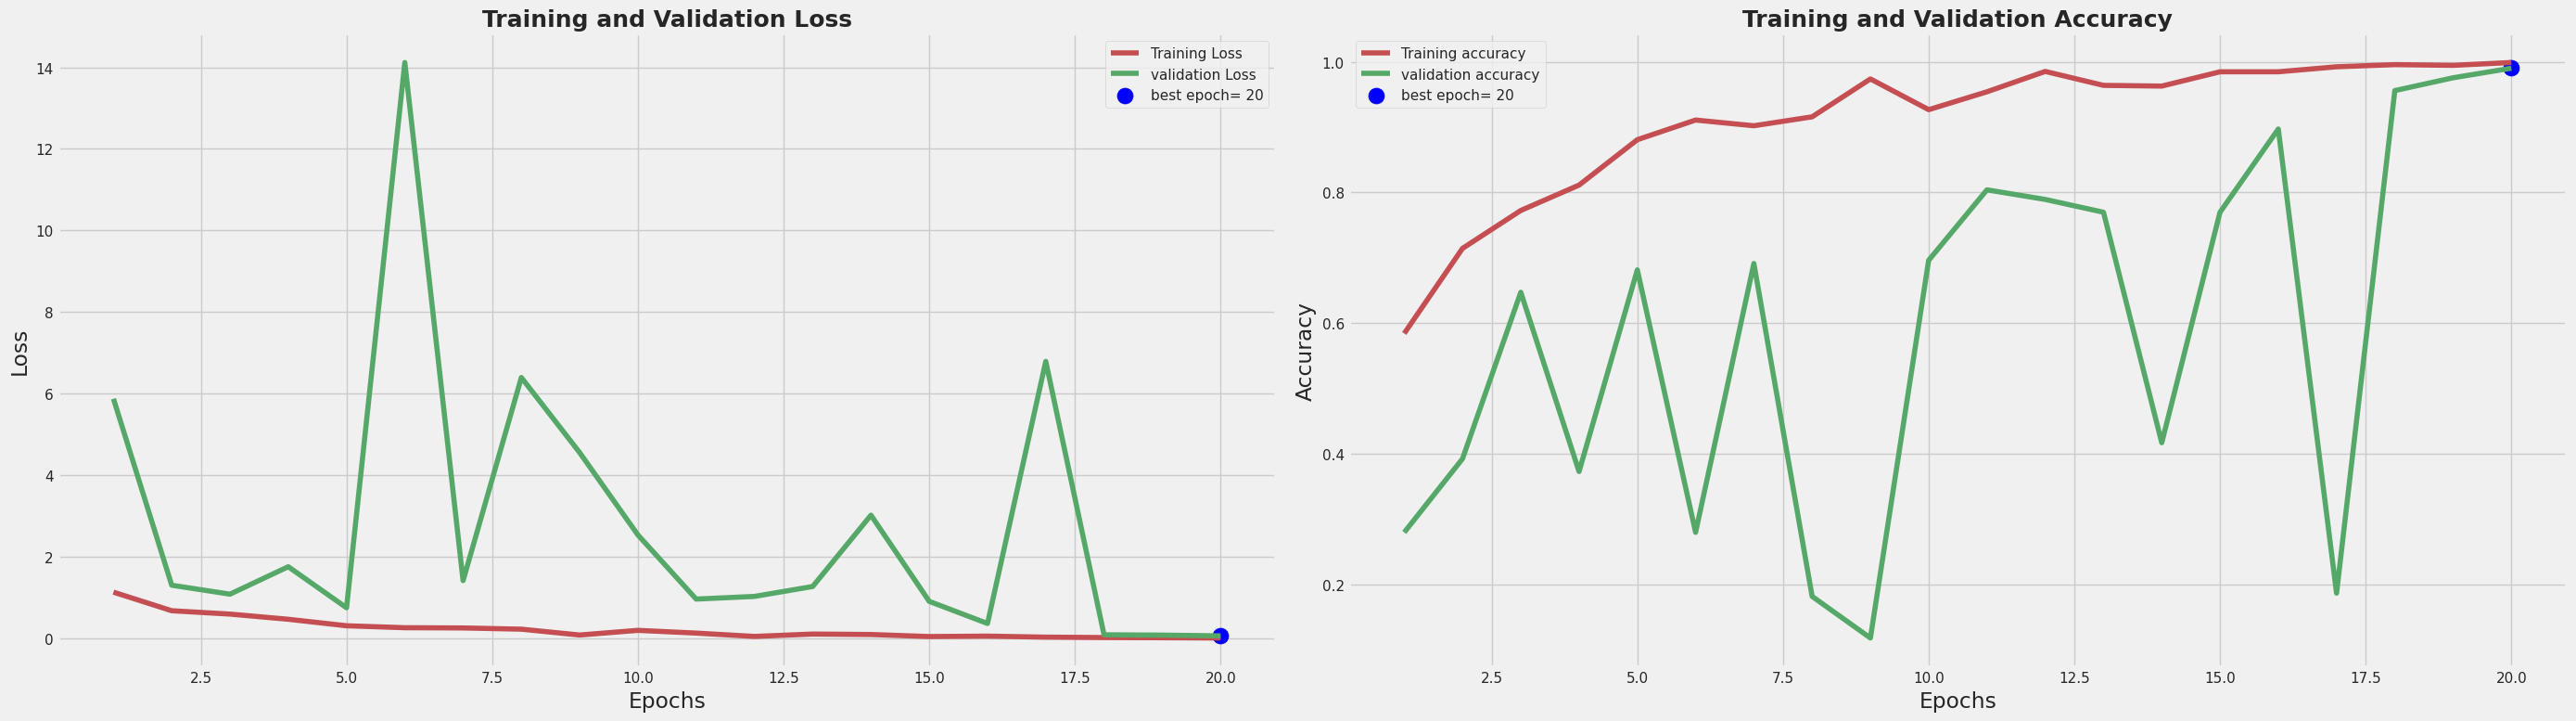

In [31]:
tr_acc   = history.history['accuracy']
tr_loss  = history.history['loss']
val_acc  = history.history['val_accuracy']
val_loss = history.history['val_loss']

idx_loss   = np.argmin(val_loss)
val_lowest = val_loss[idx_loss]
idx_acc    = np.argmax(val_acc)
val_highest= val_acc[idx_acc]

Epochs =[i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(idx_loss + 1)}'
acc_label = f'best epoch= {str(idx_acc + 1)}'

plt.figure(figsize=(28,8))
plt.style.use("fivethirtyeight")

plt.subplot(1,2,1)
plt.plot(Epochs,tr_loss,'r',label='Training Loss')
plt.plot(Epochs,val_loss,'g',label='validation Loss')
plt.scatter(idx_loss+1,val_lowest,s=150,c='blue',label= loss_label)
plt.title('Training and Validation Loss',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs,tr_acc,'r',label='Training accuracy')
plt.plot(Epochs,val_acc,'g',label='validation accuracy')
plt.scatter(idx_acc+1,val_highest,s=150,c='blue',label= acc_label)
plt.title('Training and Validation Accuracy',fontweight='bold',fontsize=18)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(
    "training_curves_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

> # ***Evaluate*** 

In [32]:
y_test = []
y_pred = []

for images, labels in validation_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_test.extend(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


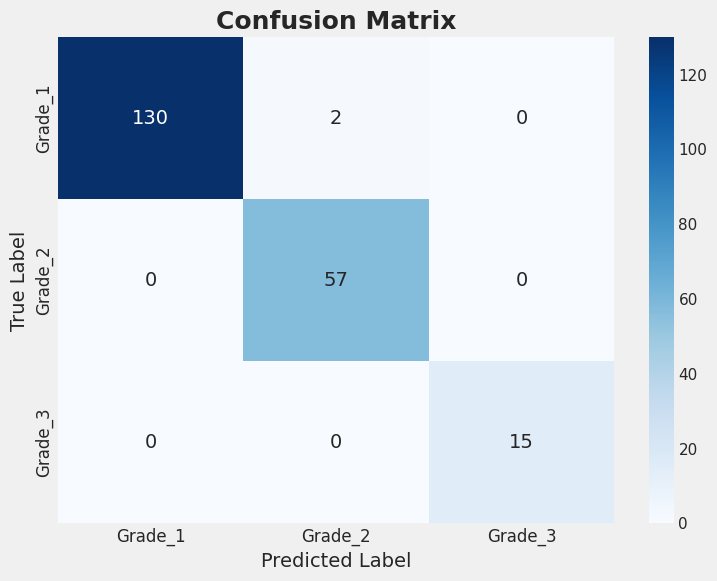

 Classification Report:

              precision    recall  f1-score   support

     Grade_1       1.00      0.98      0.99       132
     Grade_2       0.97      1.00      0.98        57
     Grade_3       1.00      1.00      1.00        15

    accuracy                           0.99       204
   macro avg       0.99      0.99      0.99       204
weighted avg       0.99      0.99      0.99       204

 Accuracy Score: 0.9902


In [33]:
con = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(con, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig(
    "Confusion_matrix_DenseNet121.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(" Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))
print(f" Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

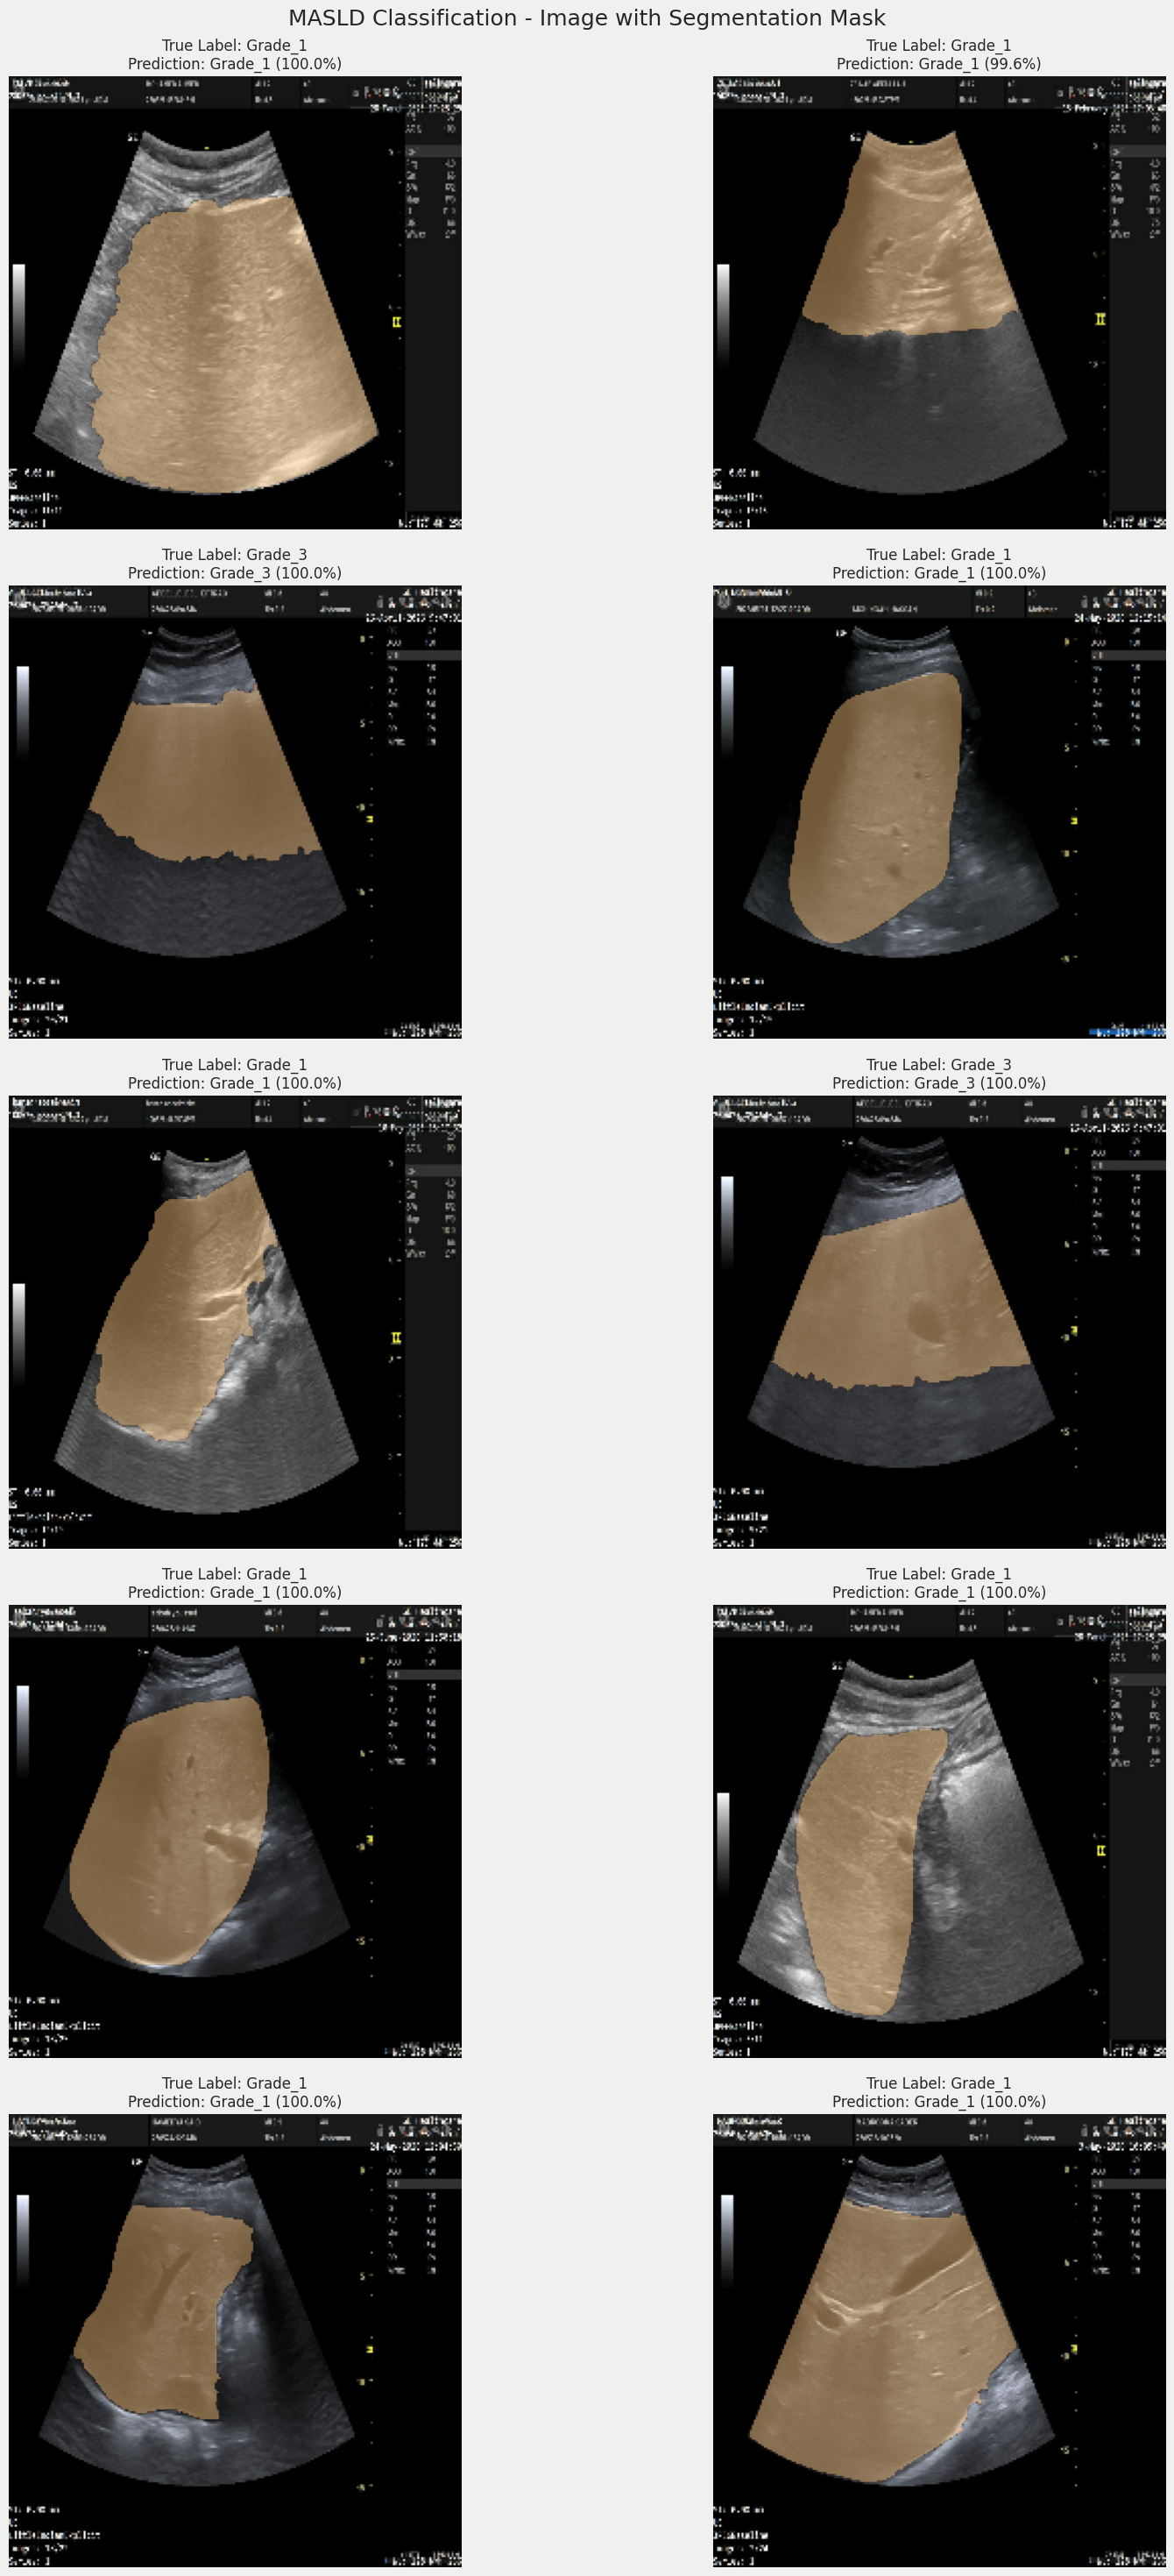

In [34]:
num_images = 10

samples = validation_df.sample(
    n=min(num_images, len(validation_df)),
    random_state=42
)

fig, axes = plt.subplots(
    5, 2,
    figsize=(20, 30)
)

axes = axes.flatten()

for i, (_, row) in enumerate(samples.iterrows()):
    image, mask, label = load_image_mask(
        tf.constant(row["image_path"]),
        tf.constant(row["mask_path"]),
        tf.constant(row["label_id"])
    )

    image = image.numpy()
    mask = mask.numpy()

    # Remove channel dimension from mask
    mask = np.squeeze(mask)
    combined = np.concatenate(
        [image, mask[..., np.newaxis]],
        axis=-1
    )
    prediction = model.predict(
        np.expand_dims(combined, axis=0),
        verbose=0
    )

    predicted_id = np.argmax(prediction[0])
    predicted_label = class_names[predicted_id]
    true_label = row["label"]
    confidence = prediction[0][predicted_id] * 100
    axes[i].imshow(image)
    # Show only mask pixels
    masked = np.ma.masked_where(
        mask <= 0,
        mask
    )

    axes[i].imshow(
        masked,
        cmap="copper",
        alpha=0.45
    )
    axes[i].set_title(
        f"True Label: {true_label}\n"
        f"Prediction: {predicted_label} "
        f"({confidence:.1f}%)",
        fontsize=12
    )
    axes[i].axis("off")
fig.suptitle(
    "MASLD Classification - Image with Segmentation Mask\n",
    fontsize=18
)

plt.tight_layout()
plt.savefig(
    "MASLD_Classification_Grades.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

> # ***Save Model*** 

In [35]:
model.save("final_DenseNet121.h5")

> # Conclusion

In this notebook, liver ultrasound images were preprocessed and augmented using an efficient on-the-fly augmentation approach. Different deep learning models were evaluated for fibrosis grade classification. **DenseNet121** achieved the best performance with **100% accuracy and perfect precision, recall, and F1-score** on the validation set, outperforming EfficientNetB0. Therefore, **DenseNet121 was selected as the final classification model**.
